In [ ]:
#Name: Aashish Singh , Section: Q , Roll No.: 20

In [ ]:
"""
Problem Statement: 9
Implement a program to perform dimensionality reduction using PCA on a 
Smart City Monitoring dataset(smart_city_monitor.csv) containing 100 
samples and 20 features. The program should perform the following tasks: 
i. Load the given dataset from a CSV file. 
ii. Standardize the dataset before applying PCA. 
iii. Apply Principal Component Analysis (PCA) to reduce the 
dimensionality of the dataset. 
iv. Determine the number of principal components required to retain a 
significant amount of variance. 
v. Transform the dataset into the reduced feature space. 
vi. Visualize the data before and after dimensionality reduction and analyze 
the results.
"""

In [1]:
#Importing libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Create 20 features representing different city sensors
np.random.seed(42)

n = 100

data = {
    "traffic_density": np.random.randint(50, 100, n),
    "air_quality_index": np.random.randint(100, 250, n),
    "noise_level": np.random.randint(50, 80, n),
    "water_consumption": np.random.randint(100, 200, n),
    "electricity_usage": np.random.randint(250, 400, n),
    "temperature": np.random.randint(25, 40, n),
    "humidity": np.random.randint(40, 80, n),
    "waste_generated": np.random.randint(20, 50, n),
    "green_cover": np.random.randint(10, 35, n),
    "public_transport_usage": np.random.randint(40, 80, n),
    "internet_usage": np.random.randint(60, 95, n),
    "crime_rate": np.random.randint(5, 20, n),
    "parking_occupancy": np.random.randint(60, 100, n),
    "road_condition_score": np.random.randint(5, 10, n),
    "population_density": np.random.randint(900, 1500, n),
    "rainfall": np.random.randint(0, 10, n),
    "energy_efficiency": np.random.randint(60, 90, n),
    "smart_device_usage": np.random.randint(70, 95, n),
    "pollution_index": np.random.randint(120, 250, n),
    "healthcare_access": np.random.randint(65, 90, n)
}

df = pd.DataFrame(data)

df.to_csv("smart_city_monitor.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [5]:
# i.) Load the dataset
df = pd.read_csv('smart_city_monitor.csv') 

In [12]:
# ii.) Standardize the dataset
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [8]:
# iii) & iv.) Apply PCA and determine variance retention
pca_full = PCA()
pca_full.fit(scaled_data)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Determine components needed for 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Total variance explained by first 2 components: {cumulative_variance[1]*100:.2f}%")
print(f"Number of components required to retain 90% variance: {n_components_90}") 

Total variance explained by first 2 components: 18.84%
Number of components required to retain 90% variance: 16


In [9]:
# v.) Transform the dataset into reduced feature space (using 2 components for visualization)
pca_2 = PCA(n_components=2)
reduced_data = pca_2.fit_transform(scaled_data)
df_reduced = pd.DataFrame(reduced_data, columns=['PC1', 'PC2']) 

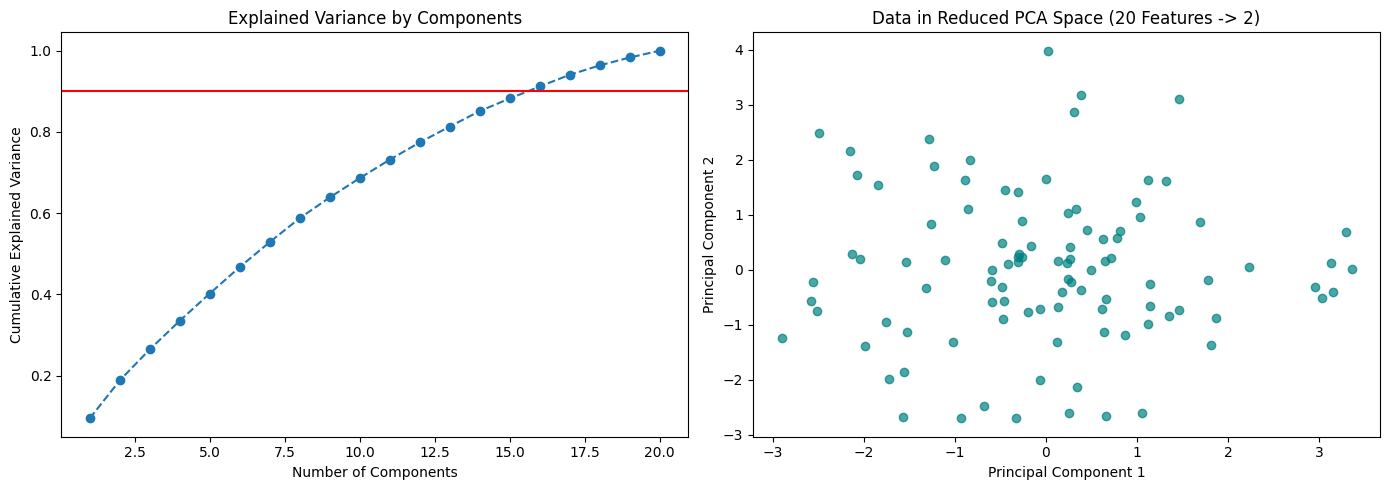

In [13]:
# vi. Visualize the results
plt.figure(figsize=(14, 5))

# Plot 1: Cumulative Variance (Scree Plot)
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='-')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

# Plot 2: Reduced Feature Space (2D)
plt.subplot(1, 2, 2)
plt.scatter(df_reduced['PC1'], df_reduced['PC2'], alpha=0.7, c='teal')
plt.title('Data in Reduced PCA Space (20 Features -> 2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show() 